In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebfit, chebval
from tensorly.decomposition import parafac
import tensorly as tl

# Define the function to be tested
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Set TensorLy backend
tl.set_backend('numpy')

# Chebyshev nodes for training
N, M = 64, 64
x_cheb = np.cos(np.pi * np.arange(N) / (N - 1))
y_cheb = np.cos(np.pi * np.arange(M) / (M - 1))
Xc, Yc = np.meshgrid(x_cheb, y_cheb, indexing='ij')

# Sample the function on Chebyshev nodes
F_train = np.vectorize(f)(Xc, Yc)

# Uniform grid for prediction
x_eval = np.linspace(-1, 1, N)
y_eval = np.linspace(-1, 1, M)
Xe, Ye = np.meshgrid(x_eval, y_eval, indexing='ij')
F_true = np.vectorize(f)(Xe, Ye)

# Store errors
ranks = range(1, 11)
rmse_errors = []
maxe_errors = []

# Iterate over ranks
for rank in ranks:
    cp_tensor = parafac(F_train, rank=rank, init='svd')
    weights, factors = cp_tensor.weights, cp_tensor.factors
    A, B = factors  # A: (N, R), B: (M, R)

    # Fit each column of A and B to Chebyshev basis
    A_cheb = np.array([chebfit(x_cheb, A[:, r], deg=N - 1) for r in range(rank)]).T
    B_cheb = np.array([chebfit(y_cheb, B[:, r], deg=M - 1) for r in range(rank)]).T

    # Predict on evaluation grid using Chebyshev evaluation
    F_pred = np.zeros((N, M))
    for r in range(rank):
        A_eval = chebval(x_eval, A_cheb[:, r])  # shape: (N,)
        B_eval = chebval(y_eval, B_cheb[:, r])  # shape: (M,)
        F_pred += weights[r] * np.outer(A_eval, B_eval)

    # Compute RMSE and MaxE between prediction and true values
    diff = F_true - F_pred
    rmse = np.sqrt(np.mean(diff**2))
    maxe = np.max(np.abs(diff))

    rmse_errors.append(rmse)
    maxe_errors.append(maxe)

    print(f"Rank {rank}, RMSE: {rmse:.2e}, MaxE: {maxe:.2e}")

# Plot RMSE and MaxE
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(ranks, rmse_errors, marker='o')
axs[0].set_yscale('log')
axs[0].set_xlabel("Rank")
axs[0].set_ylabel("Prediction RMSE (log scale)")
axs[0].set_title("RMSE vs Rank (Prediction)")
axs[0].grid(True, which='both', linestyle='--')

axs[1].plot(ranks, maxe_errors, marker='s', color='red')
axs[1].set_yscale('log')
axs[1].set_xlabel("Rank")
axs[1].set_ylabel("Prediction MaxE (log scale)")
axs[1].set_title("MaxE vs Rank (Prediction)")
axs[1].grid(True, which='both', linestyle='--')

plt.tight_layout()
plt.show()


ValueError: operands could not be broadcast together with shapes (64,64) (100,100) (64,64) 

Rank 1, RMSE: 2.48e-02, MaxE: 1.23e-01
Rank 2, RMSE: 4.65e-03, MaxE: 2.46e-02
Rank 3, RMSE: 7.86e-04, MaxE: 3.76e-03
Rank 4, RMSE: 1.28e-04, MaxE: 6.07e-04
Rank 5, RMSE: 1.98e-05, MaxE: 9.53e-05
Rank 6, RMSE: 3.09e-06, MaxE: 1.66e-05
Rank 7, RMSE: 7.43e-07, MaxE: 8.72e-06
Rank 8, RMSE: 5.82e-07, MaxE: 8.93e-06
Rank 9, RMSE: 5.78e-07, MaxE: 9.01e-06
Rank 10, RMSE: 5.78e-07, MaxE: 9.02e-06


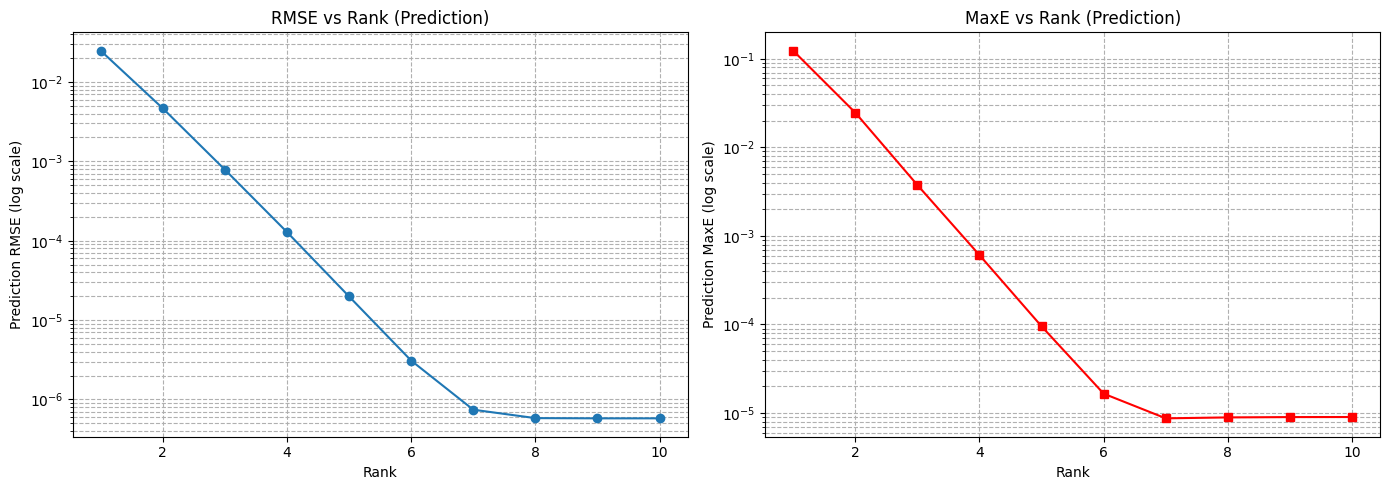

In [2]:
# Generate random (x, y) points in [-1, 1] × [-1, 1]
num_samples = N * M
x_rand = np.random.uniform(-1, 1, num_samples)
y_rand = np.random.uniform(-1, 1, num_samples)
F_true_rand = f(x_rand, y_rand)

# Store errors
rmse_errors = []
maxe_errors = []

# Iterate over ranks
for rank in ranks:
    cp_tensor = parafac(F_train, rank=rank, init='svd')
    weights, factors = cp_tensor.weights, cp_tensor.factors
    A, B = factors  # A: (N, R), B: (M, R)

    # Fit Chebyshev coefficients for each factor
    A_cheb = np.array([chebfit(x_cheb, A[:, r], deg=N - 1) for r in range(rank)]).T
    B_cheb = np.array([chebfit(y_cheb, B[:, r], deg=M - 1) for r in range(rank)]).T

    # Predict on random points
    F_pred_rand = np.zeros(num_samples)
    for r in range(rank):
        A_eval = chebval(x_rand, A_cheb[:, r])  # shape: (num_samples,)
        B_eval = chebval(y_rand, B_cheb[:, r])  # shape: (num_samples,)
        F_pred_rand += weights[r] * A_eval * B_eval

    # Compute RMSE and MaxE between prediction and true values
    diff = F_true_rand - F_pred_rand
    rmse = np.sqrt(np.mean(diff**2))
    maxe = np.max(np.abs(diff))

    rmse_errors.append(rmse)
    maxe_errors.append(maxe)

    print(f"Rank {rank}, RMSE: {rmse:.2e}, MaxE: {maxe:.2e}")

# Plot RMSE and MaxE
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(ranks, rmse_errors, marker='o')
axs[0].set_yscale('log')
axs[0].set_xlabel("Rank")
axs[0].set_ylabel("Prediction RMSE (log scale)")
axs[0].set_title("RMSE vs Rank (Prediction)")
axs[0].grid(True, which='both', linestyle='--')

axs[1].plot(ranks, maxe_errors, marker='s', color='red')
axs[1].set_yscale('log')
axs[1].set_xlabel("Rank")
axs[1].set_ylabel("Prediction MaxE (log scale)")
axs[1].set_title("MaxE vs Rank (Prediction)")
axs[1].grid(True, which='both', linestyle='--')

plt.tight_layout()
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander, chebval

# Define the function to be approximated
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Settings
N, M = 8, 8  # number of Chebyshev nodes in x and y
d_x, d_y = 7, 7  # Chebyshev degrees for x and y
R = 5  # CP rank
n_iter = 30  # ALS iterations

# Generate Chebyshev nodes
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')
F = f(X, Y)

# Generate Chebyshev basis matrices
Tx = chebvander(x_nodes, d_x)
Ty = chebvander(y_nodes, d_y)

# Initialize coefficients randomly
A_coeffs = np.random.randn(d_x + 1, R)
B_coeffs = np.random.randn(d_y + 1, R)
lambdas = np.ones(R)

# ALS Loop
for it in range(n_iter):
    # Construct approximations of A and B
    A_eval = Tx @ A_coeffs  # shape: (N, R)
    B_eval = Ty @ B_coeffs  # shape: (M, R)

    # Reconstruct tensor
    F_hat = sum(lambdas[r] * np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))

    # Compute error
    err = np.linalg.norm(F - F_hat) / np.linalg.norm(F)
    print(f"Iter {it+1}, Rel. Error: {err:.2e}")

    # === Update A_coeffs ===
    for r in range(R):
        # Fix all other ranks
        Fr = F - sum(
            lambdas[k] * np.outer(Tx @ A_coeffs[:, k], Ty @ B_coeffs[:, k])
            for k in range(R) if k != r
        )
        # Solve least squares: Fr ≈ λ_r * (Tx @ a_r) @ (Ty @ b_r)^T
        # Flatten for solving w.r.t. A
        Z = (Ty @ B_coeffs[:, r])  # shape: (M,)
        FrZ = Fr @ Z               # shape: (N,)
        A_coeffs[:, r], _, _, _ = np.linalg.lstsq(Tx * lambdas[r], FrZ, rcond=None)

    # === Update B_coeffs ===
    for r in range(R):
        Fr = F - sum(
            lambdas[k] * np.outer(Tx @ A_coeffs[:, k], Ty @ B_coeffs[:, k])
            for k in range(R) if k != r
        )
        Z = (Tx @ A_coeffs[:, r])  # shape: (N,)
        FrZ = Fr.T @ Z             # shape: (M,)
        B_coeffs[:, r], _, _, _ = np.linalg.lstsq(Ty * lambdas[r], FrZ, rcond=None)

    # === Update weights ===
    for r in range(R):
        A_r = Tx @ A_coeffs[:, r]
        B_r = Ty @ B_coeffs[:, r]
        num = np.sum(F * np.outer(A_r, B_r))
        denom = np.sum((np.outer(A_r, B_r))**2)
        print(f"Rank {r+1}, Num: {num:.2e}, Denom: {denom:.2e}")
        lambdas[r] = num / denom if denom != 0 else 0.0
        # lambdas = np.clip(lambdas, 1e-3, 1e3)

    # lambdas = np.clip(lambdas, 1e-3, 1e3)


Iter 1, Rel. Error: 1.19e+02
Rank 1, Num: -5.16e+09, Denom: 6.02e+20
Rank 2, Num: 5.40e+14, Denom: 6.30e+30
Rank 3, Num: -6.79e+21, Denom: 1.02e+45
Rank 4, Num: 8.36e+30, Denom: 1.55e+63
Rank 5, Num: -6.49e+42, Denom: 9.33e+86
Iter 2, Rel. Error: 1.57e+00
Rank 1, Num: -7.00e+258, Denom: inf
Rank 2, Num: nan, Denom: nan
Rank 3, Num: nan, Denom: nan
Rank 4, Num: nan, Denom: nan
Rank 5, Num: nan, Denom: nan
Iter 3, Rel. Error: nan
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/255125893.py:59: RuntimeWarning: invalid value encountered in matmul
  lambdas[k] * np.outer(Tx @ A_coeffs[:, k], Ty @ B_coeffs[:, k])
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/255125893.py:71: RuntimeWarning: overflow encountered in square
  denom = np.sum((np.outer(A_r, B_r))**2)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/255125893.py:69: RuntimeWarning: invalid value encountered in matmul
  B_r = Ty @ B_coeffs[:, r]
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/255125893.py:34: RuntimeWarning: invalid value encountered in matmul
  B_eval = Ty @ B_coeffs  # shape: (M, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/255125893.py:47: RuntimeWarning: invalid value encountered in matmul
  lambdas[k] * np.outer(Tx @ A_coeffs[:, k], Ty @ B_coeffs[:, k])
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/255125893.py:52: RuntimeWa

LinAlgError: SVD did not converge in Linear Least Squares

In [ ]:
# --- Prediction on random grid ---
num_test_points = 4096
x_rand = np.random.uniform(-1, 1, num_test_points)
y_rand = np.random.uniform(-1, 1, num_test_points)

# Evaluate Chebyshev basis at random points
Tx_rand = chebvander(x_rand, d_x)  # shape: (num_test_points, d_x + 1)
Ty_rand = chebvander(y_rand, d_y)  # shape: (num_test_points, d_y + 1)

# Predict using learned coefficients and weights
F_pred = np.zeros(num_test_points)
for r in range(R):
    A_r_eval = Tx_rand @ A_coeffs[:, r]  # shape: (num_test_points,)
    B_r_eval = Ty_rand @ B_coeffs[:, r]  # shape: (num_test_points,)
    F_pred += lambdas[r] * A_r_eval * B_r_eval

# True values
F_true = f(x_rand, y_rand)

# Error metrics
rmse = np.sqrt(np.mean((F_true - F_pred)**2))
maxe = np.max(np.abs(F_true - F_pred))

print(f"\nPrediction RMSE: {rmse:.2e}")
print(f"Prediction MaxE: {maxe:.2e}")



Prediction RMSE: nan
Prediction MaxE: nan


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/251191353.py:13: RuntimeWarning: divide by zero encountered in matmul
  A_r_eval = Tx_rand @ A_coeffs[:, r]  # shape: (num_test_points,)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/251191353.py:13: RuntimeWarning: overflow encountered in matmul
  A_r_eval = Tx_rand @ A_coeffs[:, r]  # shape: (num_test_points,)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/251191353.py:13: RuntimeWarning: invalid value encountered in matmul
  A_r_eval = Tx_rand @ A_coeffs[:, r]  # shape: (num_test_points,)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/251191353.py:14: RuntimeWarning: divide by zero encountered in matmul
  B_r_eval = Ty_rand @ B_coeffs[:, r]  # shape: (num_test_points,)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/251191353.py:14: RuntimeWarning: overflow encountered in matmul
  B_r_eval = Ty_rand @ B_coeffs[:, r]  # shape: (num_test_points,)
/va

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander, chebval

# Define the function to be approximated
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Settings
N, M = 64, 64
d_x, d_y = 63, 63
R = 10  # CP rank
n_iter = 1000  # ALS iterations

# Generate Chebyshev nodes
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')
F = f(X, Y)

# Generate Chebyshev basis matrices
Tx = chebvander(x_nodes, d_x)
Ty = chebvander(y_nodes, d_y)

# Initialize coefficients randomly
A_coeffs = np.random.randn(d_x + 1, R)
B_coeffs = np.random.randn(d_y + 1, R)
lambdas = np.ones(R)

epsilon = 1e-8  # Regularization strength

for it in range(n_iter):
    A_eval = Tx @ A_coeffs
    B_eval = Ty @ B_coeffs
    F_hat = sum(lambdas[r] * np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))

    err = np.sqrt(np.mean((F - F_hat)**2))
    print(f"Iter {it+1}, RMSE: {err:.2e}")

    if np.isnan(err) or err > 1e5:
        print("Stopping due to divergence.")
        break

    # Update A_coeffs
    for r in range(R):
        Fr = F - sum(
            lambdas[k] * np.outer(Tx @ A_coeffs[:, k], Ty @ B_coeffs[:, k])
            for k in range(R) if k != r
        )
        Z = Ty @ B_coeffs[:, r]
        rhs = Fr @ Z
        if lambdas[r] != 0:
            rhs /= lambdas[r]
        lhs = Tx.T @ Tx + epsilon * np.eye(Tx.shape[1])
        A_coeffs[:, r] = np.linalg.solve(lhs, Tx.T @ rhs)
        A_coeffs[:, r] /= np.linalg.norm(A_coeffs[:, r])

    # Update B_coeffs
    for r in range(R):
        Fr = F - sum(
            lambdas[k] * np.outer(Tx @ A_coeffs[:, k], Ty @ B_coeffs[:, k])
            for k in range(R) if k != r
        )
        Z = Tx @ A_coeffs[:, r]
        rhs = Fr.T @ Z
        if lambdas[r] != 0:
            rhs /= lambdas[r]
        lhs = Ty.T @ Ty + epsilon * np.eye(Ty.shape[1])
        B_coeffs[:, r] = np.linalg.solve(lhs, Ty.T @ rhs)
        B_coeffs[:, r] /= np.linalg.norm(B_coeffs[:, r])

    # Update lambdas
    for r in range(R):
        A_r = Tx @ A_coeffs[:, r]
        B_r = Ty @ B_coeffs[:, r]
        num = np.sum(F * np.outer(A_r, B_r))
        denom = np.sum((np.outer(A_r, B_r))**2)
        lambdas[r] = num / denom if denom > 1e-12 else 0.0

    lambdas = np.clip(lambdas, 1e-3, 1e3)

# -------------------- Post-training Evaluation --------------------

# Reconstructed tensor on Chebyshev grid
F_reconstructed = sum(
    lambdas[r] * np.outer(Tx @ A_coeffs[:, r], Ty @ B_coeffs[:, r])
    for r in range(R)
)

# L2 norm of difference on training grid
l2_norm_error = np.linalg.norm(F - F_reconstructed)
print(f"\nL2 norm of reconstruction error (training grid): {l2_norm_error:.4e}")

# Evaluate on new dense grid
x_eval = np.linspace(-1, 1, 100)
y_eval = np.linspace(-1, 1, 100)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')
F_true_eval = f(X_eval, Y_eval)

# Chebyshev basis for evaluation grid
Tx_eval = chebvander(x_eval, d_x)
Ty_eval = chebvander(y_eval, d_y)

# Evaluate reconstructed function
A_eval_pred = Tx_eval @ A_coeffs
B_eval_pred = Ty_eval @ B_coeffs
F_pred_eval = sum(
    lambdas[r] * np.outer(A_eval_pred[:, r], B_eval_pred[:, r])
    for r in range(R)
)

# Compute RMSE on evaluation grid
rmse_eval = np.sqrt(np.mean((F_true_eval - F_pred_eval)**2))
print(f"RMSE on [-1,1]x[-1,1] grid (100x100): {rmse_eval:.4e}")


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/3029876113.py:33: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/3029876113.py:33: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/3029876113.py:33: RuntimeWarning: invalid value encountered in matmul
  A_eval = Tx @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/3029876113.py:34: RuntimeWarning: divide by zero encountered in matmul
  B_eval = Ty @ B_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/3029876113.py:34: RuntimeWarning: overflow encountered in matmul
  B_eval = Ty @ B_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/3029876113.py:34: RuntimeWarning: invalid value encountered in matmul
  B_eval = Ty @ B_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T

Iter 1, RMSE: 1.01e+02
Iter 2, RMSE: 1.15e-01
Iter 3, RMSE: 8.77e-01
Iter 4, RMSE: 4.22e-01
Iter 5, RMSE: 2.20e-01
Iter 6, RMSE: 2.07e-01
Iter 7, RMSE: 7.18e-02
Iter 8, RMSE: 4.08e-02
Iter 9, RMSE: 3.50e-01
Iter 10, RMSE: 3.41e-01
Iter 11, RMSE: 3.03e-01
Iter 12, RMSE: 1.35e-01
Iter 13, RMSE: 1.78e-01
Iter 14, RMSE: 9.84e-02
Iter 15, RMSE: 1.13e-02
Iter 16, RMSE: 1.84e-01
Iter 17, RMSE: 5.44e-02
Iter 18, RMSE: 4.72e-02
Iter 19, RMSE: 5.97e-02
Iter 20, RMSE: 5.53e-02
Iter 21, RMSE: 2.38e-02
Iter 22, RMSE: 7.76e-03
Iter 23, RMSE: 5.21e-02
Iter 24, RMSE: 3.93e-02
Iter 25, RMSE: 1.79e-02
Iter 26, RMSE: 1.04e-02
Iter 27, RMSE: 7.31e-02
Iter 28, RMSE: 4.01e-02
Iter 29, RMSE: 1.68e-02
Iter 30, RMSE: 3.01e-02
Iter 31, RMSE: 2.62e-02
Iter 32, RMSE: 8.37e-03
Iter 33, RMSE: 4.95e-03
Iter 34, RMSE: 1.98e-02
Iter 35, RMSE: 2.11e-02
Iter 36, RMSE: 6.81e-02
Iter 37, RMSE: 4.49e-02
Iter 38, RMSE: 4.75e-02
Iter 39, RMSE: 2.37e-02
Iter 40, RMSE: 5.94e-02
Iter 41, RMSE: 3.85e-02
Iter 42, RMSE: 1.88e-02
I

/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/3029876113.py:86: RuntimeWarning: divide by zero encountered in matmul
  lambdas[r] * np.outer(Tx @ A_coeffs[:, r], Ty @ B_coeffs[:, r])
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/3029876113.py:86: RuntimeWarning: overflow encountered in matmul
  lambdas[r] * np.outer(Tx @ A_coeffs[:, r], Ty @ B_coeffs[:, r])
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/3029876113.py:86: RuntimeWarning: invalid value encountered in matmul
  lambdas[r] * np.outer(Tx @ A_coeffs[:, r], Ty @ B_coeffs[:, r])
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/3029876113.py:105: RuntimeWarning: divide by zero encountered in matmul
  A_eval_pred = Tx_eval @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/3029876113.py:105: RuntimeWarning: overflow encountered in matmul
  A_eval_pred = Tx_eval @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_4259

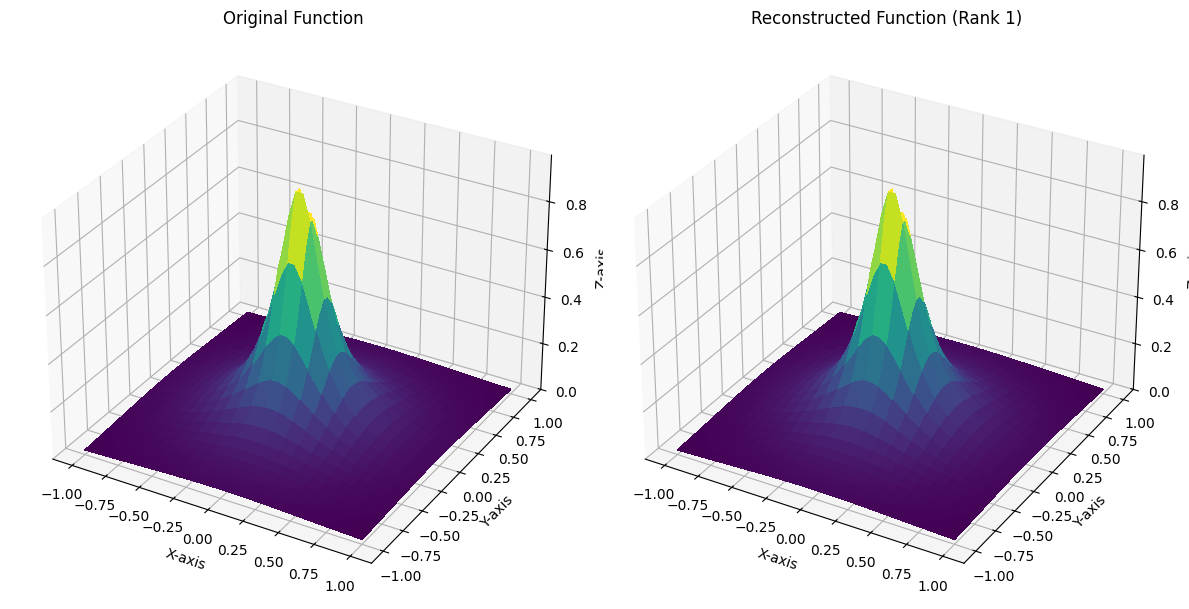

In [8]:
from matplotlib import cm

fig = plt.figure(figsize=(12, 6))

# Original function
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, F, cmap=cm.viridis, linewidth=0, antialiased=False)
ax1.set_title('Original Function')
ax1.set_xlabel('X-axis')
ax1.set_ylabel('Y-axis')
ax1.set_zlabel('Z-axis')

# Reconstructed function
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, F_hat, cmap=cm.viridis, linewidth=0, antialiased=False)
ax2.set_title(f'Reconstructed Function (Rank {rank})')
ax2.set_xlabel('X-axis')
ax2.set_ylabel('Y-axis')
ax2.set_zlabel('Z-axis')

plt.tight_layout()
plt.show()


In [9]:
# --- Prediction on random grid ---
num_test_points = 64 * 64
x_rand = np.random.uniform(-1, 1, num_test_points)
y_rand = np.random.uniform(-1, 1, num_test_points)

# Evaluate Chebyshev basis at random points
Tx_rand = chebvander(x_rand, d_x)
Ty_rand = chebvander(y_rand, d_y)

# Predict using learned coefficients and weights
F_pred = np.zeros(num_test_points)
for r in range(R):
    A_r_eval = Tx_rand @ A_coeffs[:, r]
    B_r_eval = Ty_rand @ B_coeffs[:, r]
    F_pred += lambdas[r] * A_r_eval * B_r_eval

# True values
F_true = f(x_rand, y_rand)

# Error metrics
rmse = np.sqrt(np.mean((F_true - F_pred)**2))
maxe = np.max(np.abs(F_true - F_pred))

print(f"\nPrediction RMSE: {rmse:.2e}")
print(f"Prediction MaxE: {maxe:.2e}")



Prediction RMSE: 3.19e-06
Prediction MaxE: 2.62e-05


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/2647663263.py:13: RuntimeWarning: divide by zero encountered in matmul
  A_r_eval = Tx_rand @ A_coeffs[:, r]
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/2647663263.py:13: RuntimeWarning: overflow encountered in matmul
  A_r_eval = Tx_rand @ A_coeffs[:, r]
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/2647663263.py:13: RuntimeWarning: invalid value encountered in matmul
  A_r_eval = Tx_rand @ A_coeffs[:, r]
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/2647663263.py:14: RuntimeWarning: divide by zero encountered in matmul
  B_r_eval = Ty_rand @ B_coeffs[:, r]
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/2647663263.py:14: RuntimeWarning: overflow encountered in matmul
  B_r_eval = Ty_rand @ B_coeffs[:, r]
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_42591/2647663263.py:14: RuntimeWarning: invalid value encountered in matmul
  B_r_ev

<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\h'
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/3974404723.py:20: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_title('Predicted Function $\hat{f}(x, y)$')


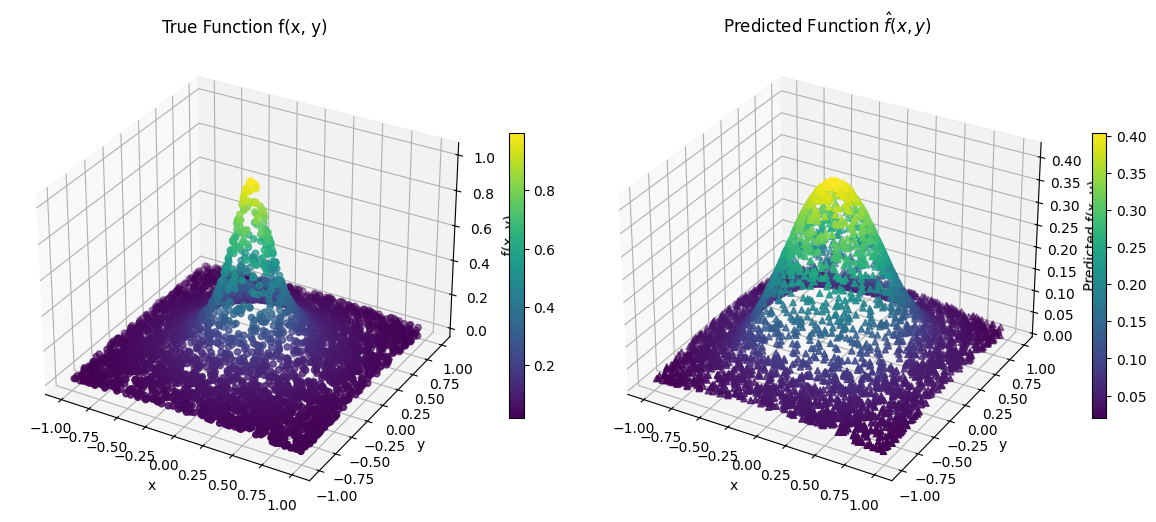

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# --- 3D Scatter Plot: f(x, y) vs predicted f(x, y) ---
fig = plt.figure(figsize=(12, 6))

# True Function
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(x_rand, y_rand, F_true, c=F_true, cmap=cm.viridis, marker='o')
ax1.set_title('True Function f(x, y)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x, y)')
fig.colorbar(sc1, ax=ax1, shrink=0.5)

# Predicted Function
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(x_rand, y_rand, F_pred, c=F_pred, cmap=cm.viridis, marker='^')
ax2.set_title('Predicted Function $\hat{f}(x, y)$')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('Predicted f(x, y)')
fig.colorbar(sc2, ax=ax2, shrink=0.5)

plt.tight_layout()
plt.show()


In [ ]:
# --- Prediction on random grid ---
x = np.linspace(-1, 1, 64)
y = np.linspace(-1, 1, 64)
X, Y = np.meshgrid(x, y, indexing='ij')

# Evaluate Chebyshev basis at random points
Tx_rand = chebvander(x_rand, d_x)  # shape: (num_test_points, d_x + 1)
Ty_rand = chebvander(y_rand, d_y)  # shape: (num_test_points, d_y + 1)

# Predict using learned coefficients and weights
F_pred = np.zeros(num_test_points)
for r in range(R):
    A_r_eval = Tx_rand @ A_coeffs[:, r]  # shape: (num_test_points,)
    B_r_eval = Ty_rand @ B_coeffs[:, r]  # shape: (num_test_points,)
    F_pred += lambdas[r] * A_r_eval * B_r_eval

# True values
F_true = f(X, Y).flatten()

# Error metrics
rmse = np.sqrt(np.mean((F_true - F_pred)**2))
maxe = np.max(np.abs(F_true - F_pred))

print(f"\nPrediction RMSE: {rmse:.2e}")
print(f"Prediction MaxE: {maxe:.2e}")



Prediction RMSE: 1.67e-01
Prediction MaxE: 9.64e-01


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/1545690266.py:13: RuntimeWarning: divide by zero encountered in matmul
  A_r_eval = Tx_rand @ A_coeffs[:, r]  # shape: (num_test_points,)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/1545690266.py:13: RuntimeWarning: overflow encountered in matmul
  A_r_eval = Tx_rand @ A_coeffs[:, r]  # shape: (num_test_points,)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/1545690266.py:13: RuntimeWarning: invalid value encountered in matmul
  A_r_eval = Tx_rand @ A_coeffs[:, r]  # shape: (num_test_points,)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/1545690266.py:14: RuntimeWarning: divide by zero encountered in matmul
  B_r_eval = Ty_rand @ B_coeffs[:, r]  # shape: (num_test_points,)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/1545690266.py:14: RuntimeWarning: overflow encountered in matmul
  B_r_eval = Ty_rand @ B_coeffs[:, r]  # shape: (num_test_points,


Prediction RMSE: 6.22e-02
Prediction MaxE: 5.84e-01


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/4061077865.py:13: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx_rand @ A_coeffs       # shape: (64, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/4061077865.py:13: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx_rand @ A_coeffs       # shape: (64, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/4061077865.py:13: RuntimeWarning: invalid value encountered in matmul
  A_eval = Tx_rand @ A_coeffs       # shape: (64, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/4061077865.py:14: RuntimeWarning: divide by zero encountered in matmul
  B_eval = Ty_rand @ B_coeffs       # shape: (64, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/4061077865.py:14: RuntimeWarning: overflow encountered in matmul
  B_eval = Ty_rand @ B_coeffs       # shape: (64, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/406

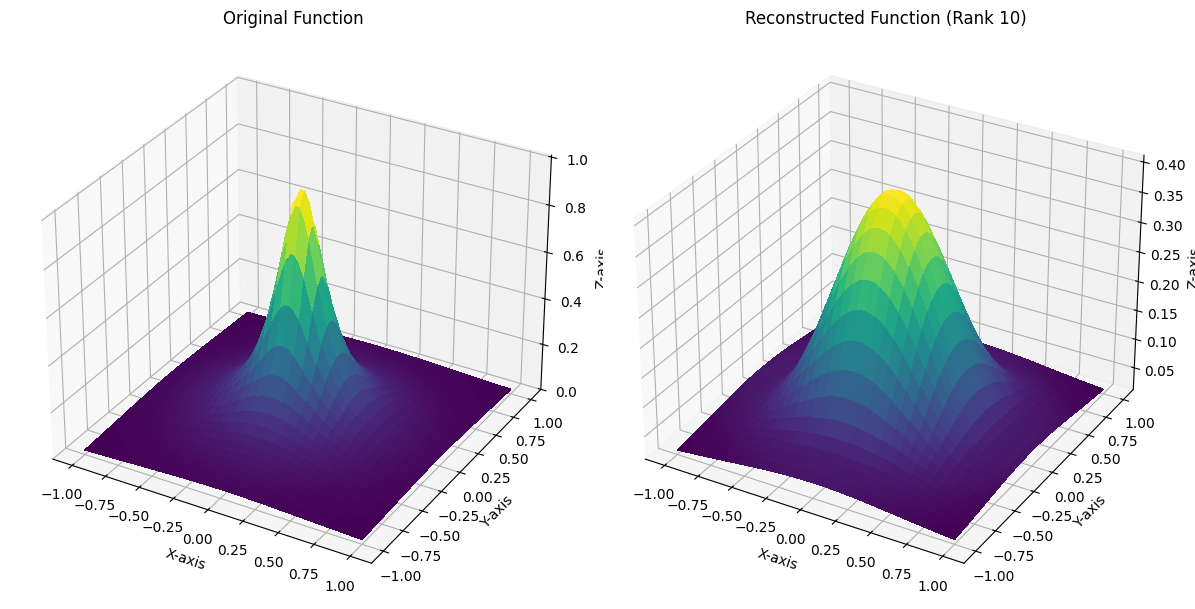

In [ ]:
from matplotlib import cm
import matplotlib.pyplot as plt
import numpy as np

# --- Prediction on 2D grid ---
x = np.linspace(-1, 1, 64)
y = np.linspace(-1, 1, 64)
X, Y = np.meshgrid(x, y, indexing='ij')

Tx_rand = chebvander(x, d_x)      # shape: (64, d_x + 1)
Ty_rand = chebvander(y, d_y)      # shape: (64, d_y + 1)

A_eval = Tx_rand @ A_coeffs       # shape: (64, R)
B_eval = Ty_rand @ B_coeffs       # shape: (64, R)

# Compute prediction over the full grid
F_pred_grid = np.zeros((64, 64))
for r in range(R):
    F_pred_grid += lambdas[r] * np.outer(A_eval[:, r], B_eval[:, r])

F_true = f(X, Y)
rmse = np.sqrt(np.mean((F_true - F_pred_grid)**2))
maxe = np.max(np.abs(F_true - F_pred_grid))

print(f"\nPrediction RMSE: {rmse:.2e}")
print(f"Prediction MaxE: {maxe:.2e}")

# --- Plotting ---
fig = plt.figure(figsize=(12, 6))

# Original function
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, F_true, cmap=cm.viridis, linewidth=0, antialiased=False)
ax1.set_title('Original Function')
ax1.set_xlabel('X-axis')
ax1.set_ylabel('Y-axis')
ax1.set_zlabel('Z-axis')

# Reconstructed function
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, F_pred_grid, cmap=cm.viridis, linewidth=0, antialiased=False)
ax2.set_title(f'Reconstructed Function (Rank {R})')
ax2.set_xlabel('X-axis')
ax2.set_ylabel('Y-axis')
ax2.set_zlabel('Z-axis')

plt.tight_layout()
plt.show()


In [ ]:
# Linspaced points (instead of Chebyshev nodes)


import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander, chebval

# Define the function to be approximated
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Settings
N, M = 64, 64
d_x, d_y = 63, 63
R = 10  # CP rank
n_iter = 1000  # ALS iterations

# Generate Chebyshev nodes
# x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
# y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
x_nodes = np.linspace(-1, 1, N)
y_nodes = np.linspace(-1, 1, M)
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')
F = f(X, Y)

# Generate Chebyshev basis matrices
Tx = chebvander(x_nodes, d_x)
Ty = chebvander(y_nodes, d_y)

# Initialize coefficients randomly
A_coeffs = np.random.randn(d_x + 1, R)
B_coeffs = np.random.randn(d_y + 1, R)
lambdas = np.ones(R)

epsilon = 1e-8  # Regularization strength

for it in range(n_iter):
    A_eval = Tx @ A_coeffs
    B_eval = Ty @ B_coeffs
    F_hat = sum(lambdas[r] * np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))

    # err = np.linalg.norm(F - F_hat) / np.linalg.norm(F)
    # Use RMSE for error reporting
    err = np.sqrt(np.mean((F - F_hat)**2))
    print(f"Iter {it+1}, RMSE: {err:.2e}")

    if np.isnan(err) or err > 1e5:
        print("Stopping due to divergence.")
        break

    # Update A_coeffs
    for r in range(R):
        Fr = F - sum(
            lambdas[k] * np.outer(Tx @ A_coeffs[:, k], Ty @ B_coeffs[:, k])
            for k in range(R) if k != r
        )
        Z = Ty @ B_coeffs[:, r]
        rhs = Fr @ Z
        if lambdas[r] != 0:
            rhs /= lambdas[r]
        lhs = Tx.T @ Tx + epsilon * np.eye(Tx.shape[1])
        A_coeffs[:, r] = np.linalg.solve(lhs, Tx.T @ rhs)
        A_coeffs[:, r] /= np.linalg.norm(A_coeffs[:, r])

    # Update B_coeffs
    for r in range(R):
        Fr = F - sum(
            lambdas[k] * np.outer(Tx @ A_coeffs[:, k], Ty @ B_coeffs[:, k])
            for k in range(R) if k != r
        )
        Z = Tx @ A_coeffs[:, r]
        rhs = Fr.T @ Z
        if lambdas[r] != 0:
            rhs /= lambdas[r]
        lhs = Ty.T @ Ty + epsilon * np.eye(Ty.shape[1])
        B_coeffs[:, r] = np.linalg.solve(lhs, Ty.T @ rhs)
        B_coeffs[:, r] /= np.linalg.norm(B_coeffs[:, r])

    # Update lambdas with tighter clipping
    for r in range(R):
        A_r = Tx @ A_coeffs[:, r]
        B_r = Ty @ B_coeffs[:, r]
        num = np.sum(F * np.outer(A_r, B_r))
        denom = np.sum((np.outer(A_r, B_r))**2)
        lambdas[r] = num / denom if denom > 1e-12 else 0.0
        # print(lambdas[r])

    lambdas = np.clip(lambdas, 1e-3, 1e3)

/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/1610288681.py:35: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/1610288681.py:35: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/1610288681.py:35: RuntimeWarning: invalid value encountered in matmul
  A_eval = Tx @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/1610288681.py:36: RuntimeWarning: divide by zero encountered in matmul
  B_eval = Ty @ B_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/1610288681.py:36: RuntimeWarning: overflow encountered in matmul
  B_eval = Ty @ B_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/1610288681.py:36: RuntimeWarning: invalid value encountered in matmul
  B_eval = Ty @ B_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T

Iter 1, RMSE: 1.00e+02
Iter 2, RMSE: 1.70e-01
Iter 3, RMSE: 1.20e+00
Iter 4, RMSE: 7.01e-01
Iter 5, RMSE: 2.59e-01
Iter 6, RMSE: 2.68e-01
Iter 7, RMSE: 2.81e-01
Iter 8, RMSE: 8.91e-02
Iter 9, RMSE: 4.23e-02
Iter 10, RMSE: 4.16e-02
Iter 11, RMSE: 7.27e-02
Iter 12, RMSE: 5.25e-02
Iter 13, RMSE: 1.58e-01
Iter 14, RMSE: 7.74e-02
Iter 15, RMSE: 7.68e-02
Iter 16, RMSE: 6.34e-02
Iter 17, RMSE: 2.27e-02
Iter 18, RMSE: 5.12e-02
Iter 19, RMSE: 2.24e-02
Iter 20, RMSE: 5.51e-02
Iter 21, RMSE: 2.93e-02
Iter 22, RMSE: 2.76e-02
Iter 23, RMSE: 1.86e-02
Iter 24, RMSE: 8.90e-03
Iter 25, RMSE: 8.22e-03
Iter 26, RMSE: 1.72e-03
Iter 27, RMSE: 1.02e-03
Iter 28, RMSE: 8.47e-04
Iter 29, RMSE: 6.18e-04
Iter 30, RMSE: 5.52e-04
Iter 31, RMSE: 6.31e-04
Iter 32, RMSE: 6.36e-04
Iter 33, RMSE: 7.74e-04
Iter 34, RMSE: 8.32e-04
Iter 35, RMSE: 9.44e-04
Iter 36, RMSE: 1.04e-03
Iter 37, RMSE: 1.13e-03
Iter 38, RMSE: 1.22e-03
Iter 39, RMSE: 1.30e-03
Iter 40, RMSE: 1.40e-03
Iter 41, RMSE: 1.51e-03
Iter 42, RMSE: 1.65e-03
I

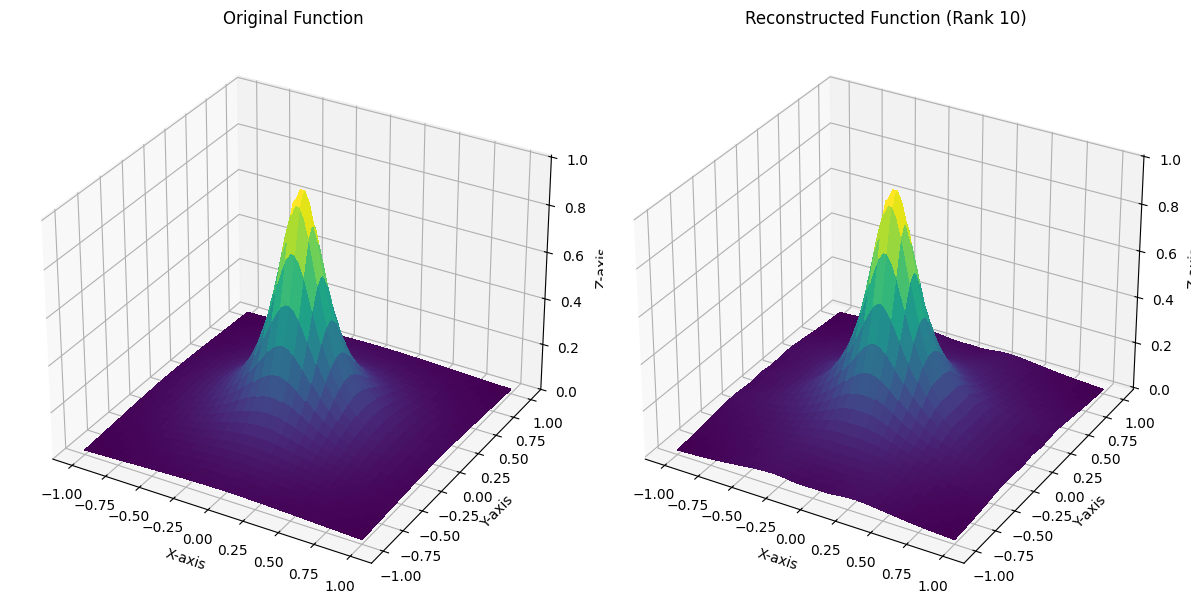

In [ ]:
from matplotlib import cm

fig = plt.figure(figsize=(12, 6))

# Original function
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, F, cmap=cm.viridis, linewidth=0, antialiased=False)
ax1.set_title('Original Function')
ax1.set_xlabel('X-axis')
ax1.set_ylabel('Y-axis')
ax1.set_zlabel('Z-axis')

# Reconstructed function
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, F_hat, cmap=cm.viridis, linewidth=0, antialiased=False)
ax2.set_title(f'Reconstructed Function (Rank {rank})')
ax2.set_xlabel('X-axis')
ax2.set_ylabel('Y-axis')
ax2.set_zlabel('Z-axis')

plt.tight_layout()
plt.show()


<>:46: SyntaxWarning: invalid escape sequence '\h'
<>:46: SyntaxWarning: invalid escape sequence '\h'
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/3841142288.py:46: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_title('Predicted Function $\hat{f}(x, y)$')
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/3841142288.py:13: RuntimeWarning: divide by zero encountered in matmul
  A_r_eval = Tx_rand @ A_coeffs[:, r]
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/3841142288.py:13: RuntimeWarning: overflow encountered in matmul
  A_r_eval = Tx_rand @ A_coeffs[:, r]
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/3841142288.py:13: RuntimeWarning: invalid value encountered in matmul
  A_r_eval = Tx_rand @ A_coeffs[:, r]
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/3841142288.py:14: RuntimeWarning: divide by zero encountered in matmul
  B_r_eval = Ty_rand @ B_coeffs[:, r]
/var/folders/8c/zb8gstqn60z7


Prediction RMSE: 7.18e-03
Prediction MaxE: 8.78e-02


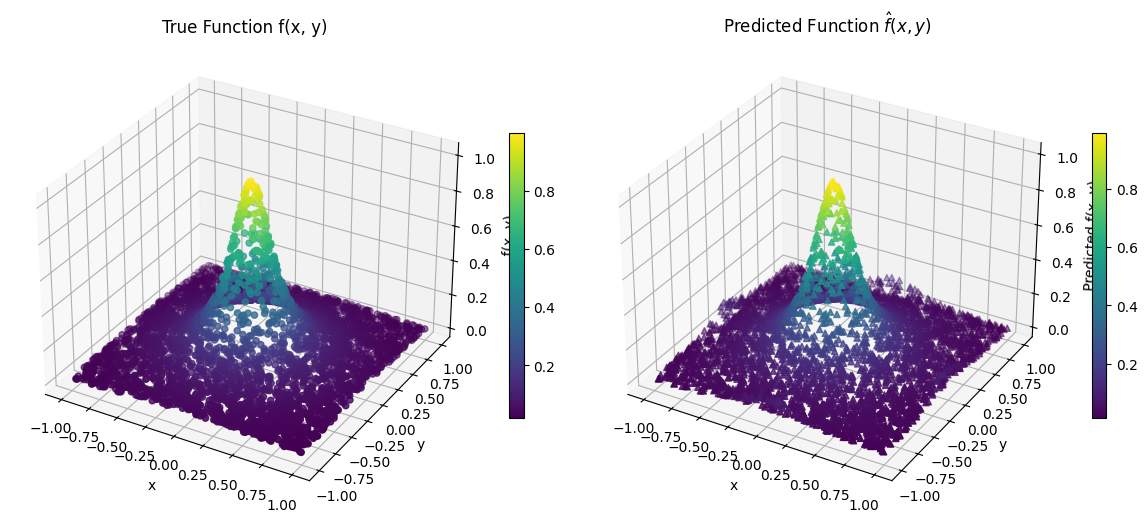

In [ ]:
# --- Prediction on random grid ---
num_test_points = 64 * 64
x_rand = np.random.uniform(-1, 1, num_test_points)
y_rand = np.random.uniform(-1, 1, num_test_points)

# Evaluate Chebyshev basis at random points
Tx_rand = chebvander(x_rand, d_x)
Ty_rand = chebvander(y_rand, d_y)

# Predict using learned coefficients and weights
F_pred = np.zeros(num_test_points)
for r in range(R):
    A_r_eval = Tx_rand @ A_coeffs[:, r]
    B_r_eval = Ty_rand @ B_coeffs[:, r]
    F_pred += lambdas[r] * A_r_eval * B_r_eval

# True values
F_true = f(x_rand, y_rand)

# Error metrics
rmse = np.sqrt(np.mean((F_true - F_pred)**2))
maxe = np.max(np.abs(F_true - F_pred))

print(f"\nPrediction RMSE: {rmse:.2e}")
print(f"Prediction MaxE: {maxe:.2e}")

import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# --- 3D Scatter Plot: f(x, y) vs predicted f(x, y) ---
fig = plt.figure(figsize=(12, 6))

# True Function
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(x_rand, y_rand, F_true, c=F_true, cmap=cm.viridis, marker='o')
ax1.set_title('True Function f(x, y)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x, y)')
fig.colorbar(sc1, ax=ax1, shrink=0.5)

# Predicted Function
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(x_rand, y_rand, F_pred, c=F_pred, cmap=cm.viridis, marker='^')
ax2.set_title('Predicted Function $\hat{f}(x, y)$')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('Predicted f(x, y)')
fig.colorbar(sc2, ax=ax2, shrink=0.5)

plt.tight_layout()
plt.show()


In [ ]:
# HIGHER DEGREE (WITH CHEBYSHEV NODES)

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander, chebval

# Define the function to be approximated
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Settings
N, M = 64, 64
d_x, d_y = 63, 63
R = 10  # CP rank
n_iter = 1000  # ALS iterations

# Generate Chebyshev nodes
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')
F = f(X, Y)

# Generate Chebyshev basis matrices
Tx = chebvander(x_nodes, d_x)
Ty = chebvander(y_nodes, d_y)

# Initialize coefficients randomly
A_coeffs = np.random.randn(d_x + 1, R)
B_coeffs = np.random.randn(d_y + 1, R)
lambdas = np.ones(R)

epsilon = 1e-8  # Regularization strength

for it in range(n_iter):
    A_eval = Tx @ A_coeffs
    B_eval = Ty @ B_coeffs
    F_hat = sum(lambdas[r] * np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))

    # err = np.linalg.norm(F - F_hat) / np.linalg.norm(F)
    # Use RMSE for error reporting
    err = np.sqrt(np.mean((F - F_hat)**2))
    print(f"Iter {it+1}, RMSE: {err:.2e}")

    if np.isnan(err) or err > 1e5:
        print("Stopping due to divergence.")
        break

    # Update A_coeffs
    for r in range(R):
        Fr = F - sum(
            lambdas[k] * np.outer(Tx @ A_coeffs[:, k], Ty @ B_coeffs[:, k])
            for k in range(R) if k != r
        )
        Z = Ty @ B_coeffs[:, r]
        rhs = Fr @ Z
        if lambdas[r] != 0:
            rhs /= lambdas[r]
        lhs = Tx.T @ Tx + epsilon * np.eye(Tx.shape[1])
        A_coeffs[:, r] = np.linalg.solve(lhs, Tx.T @ rhs)
        A_coeffs[:, r] /= np.linalg.norm(A_coeffs[:, r])

    # Update B_coeffs
    for r in range(R):
        Fr = F - sum(
            lambdas[k] * np.outer(Tx @ A_coeffs[:, k], Ty @ B_coeffs[:, k])
            for k in range(R) if k != r
        )
        Z = Tx @ A_coeffs[:, r]
        rhs = Fr.T @ Z
        if lambdas[r] != 0:
            rhs /= lambdas[r]
        lhs = Ty.T @ Ty + epsilon * np.eye(Ty.shape[1])
        B_coeffs[:, r] = np.linalg.solve(lhs, Ty.T @ rhs)
        B_coeffs[:, r] /= np.linalg.norm(B_coeffs[:, r])

    # Update lambdas with tighter clipping
    for r in range(R):
        A_r = Tx @ A_coeffs[:, r]
        B_r = Ty @ B_coeffs[:, r]
        num = np.sum(F * np.outer(A_r, B_r))
        denom = np.sum((np.outer(A_r, B_r))**2)
        lambdas[r] = num / denom if denom > 1e-12 else 0.0
        # print(lambdas[r])

    lambdas = np.clip(lambdas, 1e-3, 1e3)

/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/2155055672.py:35: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/2155055672.py:35: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/2155055672.py:35: RuntimeWarning: invalid value encountered in matmul
  A_eval = Tx @ A_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/2155055672.py:36: RuntimeWarning: divide by zero encountered in matmul
  B_eval = Ty @ B_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/2155055672.py:36: RuntimeWarning: overflow encountered in matmul
  B_eval = Ty @ B_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/2155055672.py:36: RuntimeWarning: invalid value encountered in matmul
  B_eval = Ty @ B_coeffs
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T

Iter 1, RMSE: 1.04e+02
Iter 2, RMSE: 1.15e-01
Iter 3, RMSE: 8.90e-01
Iter 4, RMSE: 3.98e-01
Iter 5, RMSE: 6.62e-01
Iter 6, RMSE: 2.86e-01
Iter 7, RMSE: 1.47e-01
Iter 8, RMSE: 1.77e-01
Iter 9, RMSE: 1.17e-01
Iter 10, RMSE: 6.87e-01
Iter 11, RMSE: 3.93e-01
Iter 12, RMSE: 3.93e-01
Iter 13, RMSE: 1.78e-01
Iter 14, RMSE: 1.10e-01
Iter 15, RMSE: 2.71e-02
Iter 16, RMSE: 4.02e-01
Iter 17, RMSE: 1.13e-01
Iter 18, RMSE: 2.44e-01
Iter 19, RMSE: 1.32e-01
Iter 20, RMSE: 4.06e-02
Iter 21, RMSE: 2.03e-02
Iter 22, RMSE: 1.67e-02
Iter 23, RMSE: 1.22e-02
Iter 24, RMSE: 1.04e-02
Iter 25, RMSE: 8.46e-03
Iter 26, RMSE: 1.03e-02
Iter 27, RMSE: 1.61e-02
Iter 28, RMSE: 8.36e-03
Iter 29, RMSE: 1.02e-02
Iter 30, RMSE: 2.86e-02
Iter 31, RMSE: 1.13e-01
Iter 32, RMSE: 4.36e-02
Iter 33, RMSE: 6.78e-02
Iter 34, RMSE: 1.53e-02
Iter 35, RMSE: 9.30e-03
Iter 36, RMSE: 4.82e-02
Iter 37, RMSE: 7.69e-02
Iter 38, RMSE: 1.02e-01
Iter 39, RMSE: 3.58e-02
Iter 40, RMSE: 3.04e-02
Iter 41, RMSE: 3.46e-02
Iter 42, RMSE: 1.53e-02
I

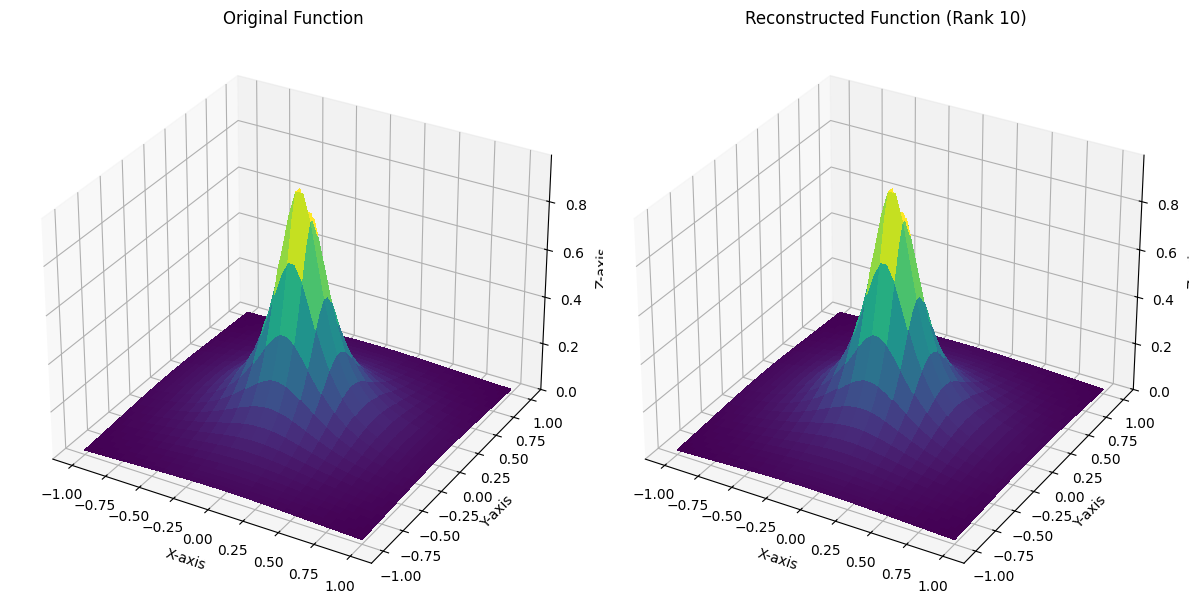

In [ ]:
from matplotlib import cm

fig = plt.figure(figsize=(12, 6))

# Original function
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, F, cmap=cm.viridis, linewidth=0, antialiased=False)
ax1.set_title('Original Function')
ax1.set_xlabel('X-axis')
ax1.set_ylabel('Y-axis')
ax1.set_zlabel('Z-axis')

# Reconstructed function
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, F_hat, cmap=cm.viridis, linewidth=0, antialiased=False)
ax2.set_title(f'Reconstructed Function (Rank {rank})')
ax2.set_xlabel('X-axis')
ax2.set_ylabel('Y-axis')
ax2.set_zlabel('Z-axis')

plt.tight_layout()
plt.show()



Prediction RMSE: 9.46e-07
Prediction MaxE: 9.91e-06


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/4061077865.py:13: RuntimeWarning: divide by zero encountered in matmul
  A_eval = Tx_rand @ A_coeffs       # shape: (64, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/4061077865.py:13: RuntimeWarning: overflow encountered in matmul
  A_eval = Tx_rand @ A_coeffs       # shape: (64, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/4061077865.py:13: RuntimeWarning: invalid value encountered in matmul
  A_eval = Tx_rand @ A_coeffs       # shape: (64, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/4061077865.py:14: RuntimeWarning: divide by zero encountered in matmul
  B_eval = Ty_rand @ B_coeffs       # shape: (64, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/4061077865.py:14: RuntimeWarning: overflow encountered in matmul
  B_eval = Ty_rand @ B_coeffs       # shape: (64, R)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/406

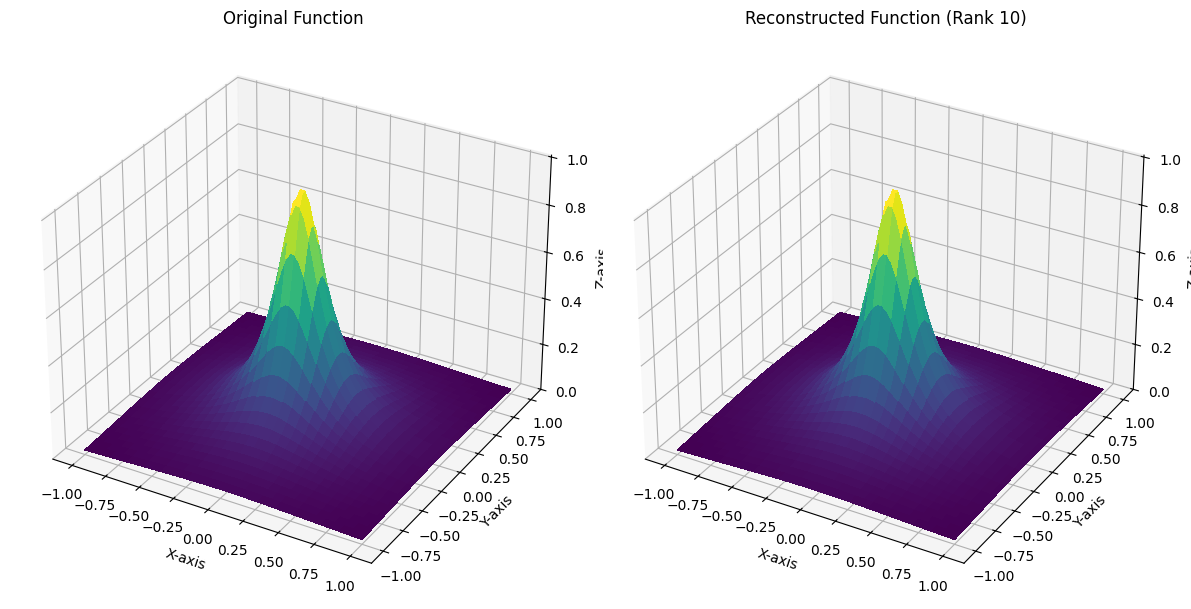

In [ ]:
from matplotlib import cm
import matplotlib.pyplot as plt
import numpy as np

# --- Prediction on 2D grid ---
x = np.linspace(-1, 1, 64)
y = np.linspace(-1, 1, 64)
X, Y = np.meshgrid(x, y, indexing='ij')

Tx_rand = chebvander(x, d_x)      # shape: (64, d_x + 1)
Ty_rand = chebvander(y, d_y)      # shape: (64, d_y + 1)

A_eval = Tx_rand @ A_coeffs       # shape: (64, R)
B_eval = Ty_rand @ B_coeffs       # shape: (64, R)

# Compute prediction over the full grid
F_pred_grid = np.zeros((64, 64))
for r in range(R):
    F_pred_grid += lambdas[r] * np.outer(A_eval[:, r], B_eval[:, r])

F_true = f(X, Y)
rmse = np.sqrt(np.mean((F_true - F_pred_grid)**2))
maxe = np.max(np.abs(F_true - F_pred_grid))

print(f"\nPrediction RMSE: {rmse:.2e}")
print(f"Prediction MaxE: {maxe:.2e}")

# --- Plotting ---
fig = plt.figure(figsize=(12, 6))

# Original function
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, F_true, cmap=cm.viridis, linewidth=0, antialiased=False)
ax1.set_title('Original Function')
ax1.set_xlabel('X-axis')
ax1.set_ylabel('Y-axis')
ax1.set_zlabel('Z-axis')

# Reconstructed function
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, F_pred_grid, cmap=cm.viridis, linewidth=0, antialiased=False)
ax2.set_title(f'Reconstructed Function (Rank {R})')
ax2.set_xlabel('X-axis')
ax2.set_ylabel('Y-axis')
ax2.set_zlabel('Z-axis')

plt.tight_layout()
plt.show()


<>:46: SyntaxWarning: invalid escape sequence '\h'
<>:46: SyntaxWarning: invalid escape sequence '\h'
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/3841142288.py:46: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_title('Predicted Function $\hat{f}(x, y)$')
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/3841142288.py:13: RuntimeWarning: divide by zero encountered in matmul
  A_r_eval = Tx_rand @ A_coeffs[:, r]
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/3841142288.py:13: RuntimeWarning: overflow encountered in matmul
  A_r_eval = Tx_rand @ A_coeffs[:, r]
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/3841142288.py:13: RuntimeWarning: invalid value encountered in matmul
  A_r_eval = Tx_rand @ A_coeffs[:, r]
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_28177/3841142288.py:14: RuntimeWarning: divide by zero encountered in matmul
  B_r_eval = Ty_rand @ B_coeffs[:, r]
/var/folders/8c/zb8gstqn60z7


Prediction RMSE: 9.27e-07
Prediction MaxE: 1.02e-05


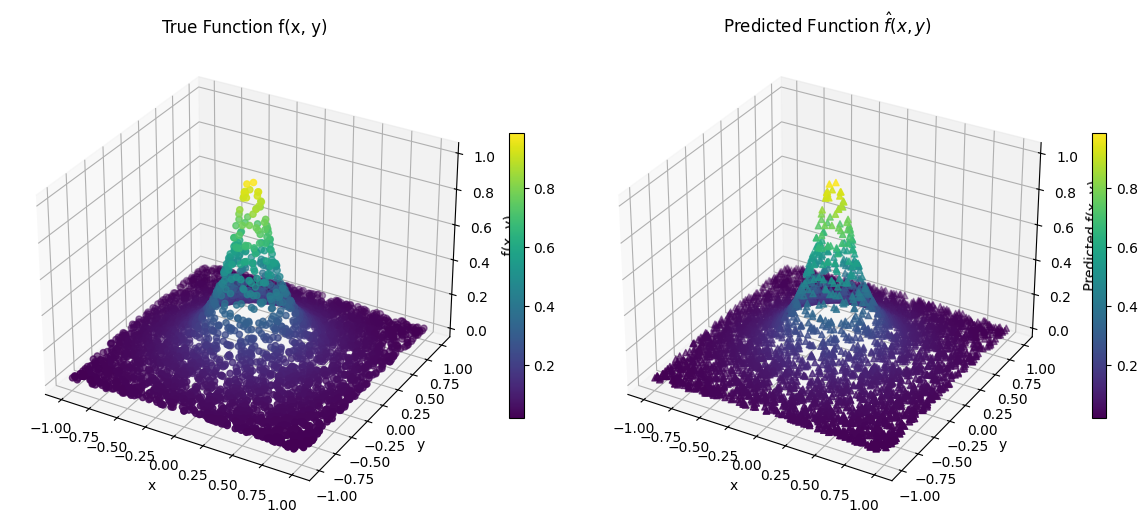

In [ ]:
# --- Prediction on random grid ---
num_test_points = 64 * 64
x_rand = np.random.uniform(-1, 1, num_test_points)
y_rand = np.random.uniform(-1, 1, num_test_points)

# Evaluate Chebyshev basis at random points
Tx_rand = chebvander(x_rand, d_x)
Ty_rand = chebvander(y_rand, d_y)

# Predict using learned coefficients and weights
F_pred = np.zeros(num_test_points)
for r in range(R):
    A_r_eval = Tx_rand @ A_coeffs[:, r]
    B_r_eval = Ty_rand @ B_coeffs[:, r]
    F_pred += lambdas[r] * A_r_eval * B_r_eval

# True values
F_true = f(x_rand, y_rand)

# Error metrics
rmse = np.sqrt(np.mean((F_true - F_pred)**2))
maxe = np.max(np.abs(F_true - F_pred))

print(f"\nPrediction RMSE: {rmse:.2e}")
print(f"Prediction MaxE: {maxe:.2e}")

import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# --- 3D Scatter Plot: f(x, y) vs predicted f(x, y) ---
fig = plt.figure(figsize=(12, 6))

# True Function
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(x_rand, y_rand, F_true, c=F_true, cmap=cm.viridis, marker='o')
ax1.set_title('True Function f(x, y)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x, y)')
fig.colorbar(sc1, ax=ax1, shrink=0.5)

# Predicted Function
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(x_rand, y_rand, F_pred, c=F_pred, cmap=cm.viridis, marker='^')
ax2.set_title('Predicted Function $\hat{f}(x, y)$')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('Predicted f(x, y)')
fig.colorbar(sc2, ax=ax2, shrink=0.5)

plt.tight_layout()
plt.show()


In [ ]:
print(lambdas)
print(A_coeffs)
print(B_coeffs)

[0.01207817 0.00258443 0.001      0.001      0.001      0.001
 0.001      0.001      0.05271119 0.17909425]
[[-8.61491633e-01  5.89969187e-02  4.32955573e-01  6.28529857e-01
  -6.09282211e-01  6.04395263e-01 -4.11214809e-01 -3.75126833e-01
  -8.57216040e-01 -5.37251327e-01]
 [ 7.24078804e-04  2.38274474e-03 -1.26683728e-03 -3.44084500e-03
   2.98650921e-03 -3.54644325e-03  2.10316929e-03  9.66330827e-04
   3.38757849e-06  1.41437929e-06]
 [-2.89526116e-01 -5.21398276e-01 -3.73543276e-01  1.42022241e-01
   7.39157956e-01 -6.81567683e-01  8.00101538e-01  5.24481247e-01
   4.96174121e-01  6.57266421e-01]
 [-7.81712371e-04 -2.57240097e-03  1.36767194e-03  3.71472135e-03
  -3.22422253e-03  3.82872504e-03 -2.27057261e-03 -1.04324662e-03
  -3.65721525e-06 -1.52695783e-06]
 [ 3.39970858e-01  9.26164388e-02 -3.31508890e-01  3.62376092e-01
   4.03262606e-02  3.22151953e-01 -3.01870287e-01 -7.18408007e-01
  -1.11625520e-01 -4.09242247e-01]
 [ 5.68143660e-04  1.86960496e-03 -9.94015537e-04 -2.6998